In [ ]:
# Estudiante: Julián David Rojas Román

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga del dataset
df = pd.read_csv('laptop_pricing_dataset_mod1.csv')

# Visualización preliminar
print(df.head())
print(df.info())

   Unnamed: 0 Manufacturer  Category     Screen  GPU  OS  CPU_core  \
0           0         Acer         4  IPS Panel    2   1         5   
1           1         Dell         3    Full HD    1   1         3   
2           2         Dell         3    Full HD    1   1         7   
3           3         Dell         4  IPS Panel    2   1         5   
4           4           HP         4    Full HD    2   1         7   

   Screen_Size_cm  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0          35.560            1.6       8             256       1.60    978  
1          39.624            2.0       4             256       2.20    634  
2          39.624            2.7       8             256       2.20    946  
3          33.782            1.6       8             128       1.22   1244  
4          39.624            1.8       8             256       1.91    837  
<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          No

In [3]:
# Tarea 1: Tratamiento de Valores Faltantes
# Sustitución de "?" por NaN para que pandas los reconozca
df.replace('?', np.nan, inplace=True)

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,233,Lenovo,4,IPS Panel,2,1,7,35.560,2.6,8,256,1.70,1891
234,234,Toshiba,3,Full HD,2,1,5,33.782,2.4,8,256,1.20,1950
235,235,Lenovo,4,IPS Panel,2,1,5,30.480,2.6,8,256,1.36,2236
236,236,Lenovo,3,Full HD,3,1,5,39.624,2.5,6,256,2.40,883


In [4]:
# Tarea 2: Reemplazo de valores con media y frecuencia
# Imputación de Peso_kg con la media
avg_weight = df['Weight_kg'].astype('float').mean(axis=0)
df['Weight_kg'].replace(np.nan, avg_weight, inplace=True)

# Imputación con el valor más frecuente (Moda)
common_screen = df['Screen_Size_cm'].value_counts().idxmax()
df['Screen_Size_cm'].replace(np.nan, common_screen, inplace=True)

C:\Users\roman\AppData\Local\Temp\ipykernel_10572\3494658981.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Weight_kg'].replace(np.nan, avg_weight, inplace=True)
C:\Users\roman\AppData\Local\Temp\ipykernel_10572\3494658981.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained a

0      35.560
1      39.624
2      39.624
3      33.782
4      39.624
        ...  
233    35.560
234    33.782
235    30.480
236    39.624
237    35.560
Name: Screen_Size_cm, Length: 238, dtype: float64

In [5]:
# Tarea 3: Corrección de tipos de datos
df[['Weight_kg', 'Screen_Size_cm']] = df[['Weight_kg', 'Screen_Size_cm']].astype('float')

In [ ]:
# Tarea 4: Estandarización y Normalización
# Conversión de cm a pulgadas y kg a libras
df['Screen_Size_cm'] = df['Screen_Size_cm'].replace(np.nan, common_screen)
df['Weight_kg'] = df['Weight_kg'].replace(np.nan, avg_weight)

# Renombrar columnas para reflejar las nuevas unidades
df.rename(columns={'Screen_Size_cm': 'Screen_Size_inch', 'Weight_kg': 'Weight_pounds'}, inplace=True)

# Normalización de CPU_frequency con respecto al máximo
df['CPU_frequency'] = df['CPU_frequency'] / df['CPU_frequency'].max()

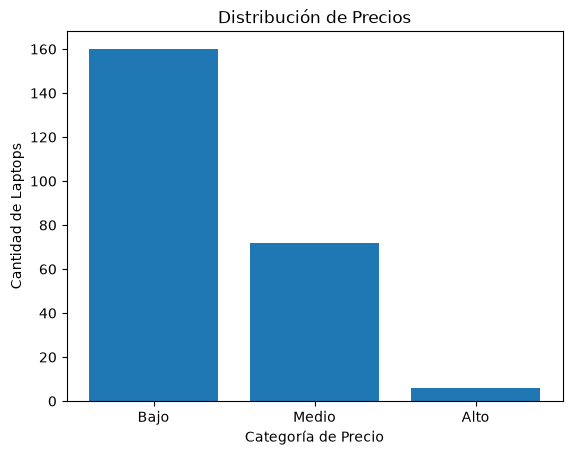

In [7]:
# Tarea 5: Agrupamiento (Binning)
bins = np.linspace(min(df['Price']), max(df['Price']), 4)
group_names = ['Bajo', 'Medio', 'Alto']
df['Agrupamiento de precios'] = pd.cut(df['Price'], bins, labels=group_names, include_lowest=True)

# Visualización del agrupamiento
plt.bar(group_names, df['Agrupamiento de precios'].value_counts())
plt.xlabel('Categoría de Precio')
plt.ylabel('Cantidad de Laptops')
plt.title('Distribución de Precios')
plt.show()

In [8]:
# Tarea 6: Variables indicadoras (One Hot Encoding)
dummy_variable = pd.get_dummies(df['Screen'])
dummy_variable.rename(columns={'Full HD': 'Pantalla-Full_HD', 'IPS Panel': 'Pantalla-IPS_panel'}, inplace=True)

# Concatenar y eliminar columna original
df = pd.concat([df, dummy_variable], axis=1)
df.drop('Screen', axis=1, inplace=True)

# Verificación final
print(df.head())

   Unnamed: 0 Manufacturer  Category  GPU  OS  CPU_core  Screen_Size_inch  \
0           0         Acer         4    2   1         5              14.0   
1           1         Dell         3    1   1         3              15.6   
2           2         Dell         3    1   1         7              15.6   
3           3         Dell         4    2   1         5              13.3   
4           4           HP         4    2   1         7              15.6   

   CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_pounds  Price  \
0       0.551724       8             256        3.52800    978   
1       0.689655       4             256        4.85100    634   
2       0.931034       8             256        4.85100    946   
3       0.551724       8             128        2.69010   1244   
4       0.620690       8             256        4.21155    837   

  Agrupamiento de precios  Pantalla-Full_HD  Pantalla-IPS_panel  
0                    Bajo             False                True  
1       